In [2]:
import pandas as pd
from seaborn import lineplot
%load_ext autoreload
%autoreload 2
from visualisierungen import *

In [3]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr             rechtsform_name  \
0  1.0  1848-09-12  1848-1851  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  berecht  ...  zustimmung_p-kdk  zustimmung_p-kkjpd  \
0      1.0        72.83      NaN  ...               NaN                 NaN   
1      0.0  

# Postion-Bundesrat vs. Zustimmung

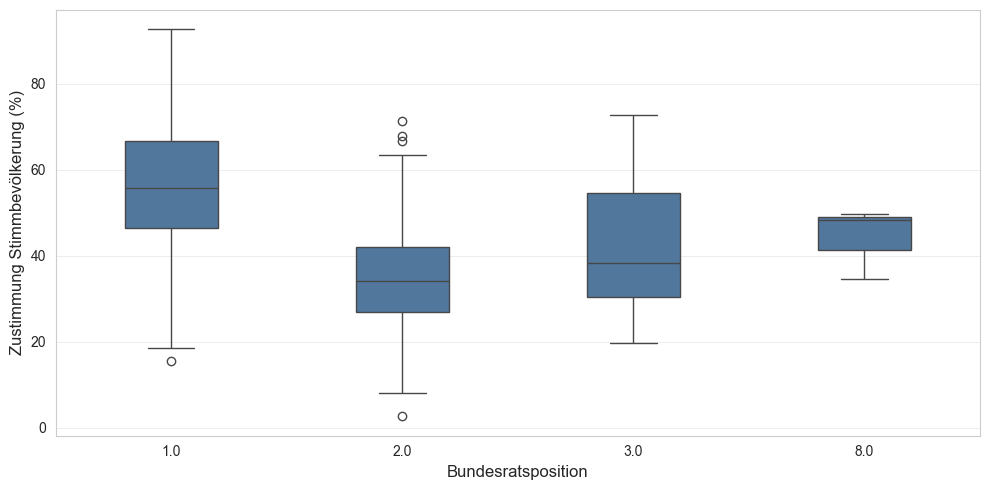

In [4]:
boxplot(df, df["br-pos"], df["volkja-proz"], titel="", xlabel="Bundesratsposition", ylabel="Zustimmung Stimmbevölkerung (%)", farbe=None)


## Parteien

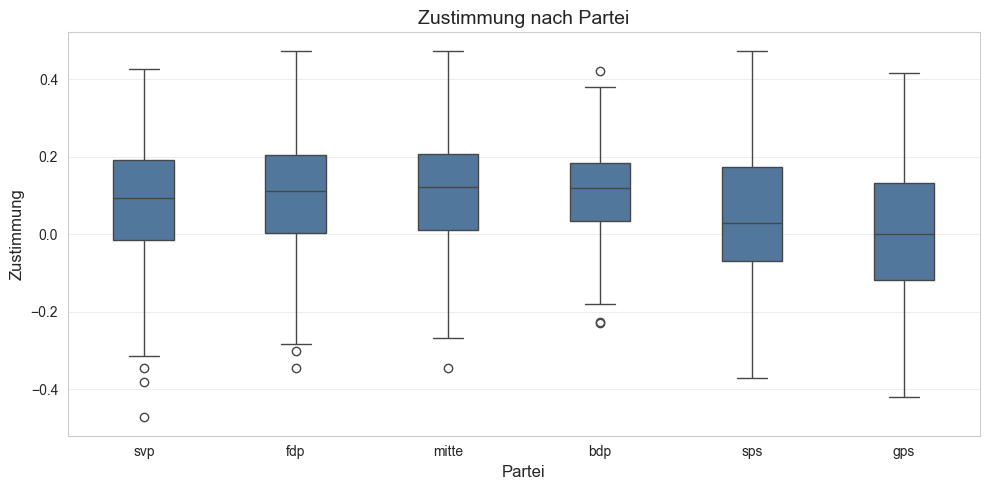

In [5]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte","zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"]

df_long = df[["legisjahr"] + partei_cols].melt(
    id_vars="legisjahr", var_name="partei", value_name="zustimmung")

df_long['partei'] = df_long['partei'].str.replace('zustimmung_p-', '')

df_long_mean = df_long.groupby("partei")["zustimmung"].mean().reset_index()

boxplot(df_long, x="partei", y="zustimmung",
        titel="Zustimmung nach Partei",
        xlabel="Partei", ylabel="Zustimmung",
        figsize=(10, 5))

## Verbände

In [6]:
gruppen = {
    'Bundesrat': ['zustimmung_br-pos'],
    'Wirtschaft': ['zustimmung_p-sgv', 'zustimmung_p-sbv', 'zustimmung_p-sav'],
    'Gewerkschaften': ['zustimmung_p-sgb', 'zustimmung_p-travs', 'zustimmung_p-vpod'],
    'Verkehr': ['zustimmung_p-tcs', 'zustimmung_p-vcs', 'zustimmung_p-acs', 'zustimmung_p-voev'],
    'Andere': ['zustimmung_p-sbk', 'zustimmung_p-ssv', 'zustimmung_p-eco', 'zustimmung_p-ucsp', 'zustimmung_p-vsa'],
}

frames = []
for gruppe, cols in gruppen.items():
    temp = df[cols].melt(var_name='organisation', value_name='zustimmung')
    temp['organisation'] = temp['organisation'].str.replace('zustimmung_p-', '')
    temp['gruppe'] = gruppe
    frames.append(temp)

df_verb = pd.concat(frames, ignore_index=True)

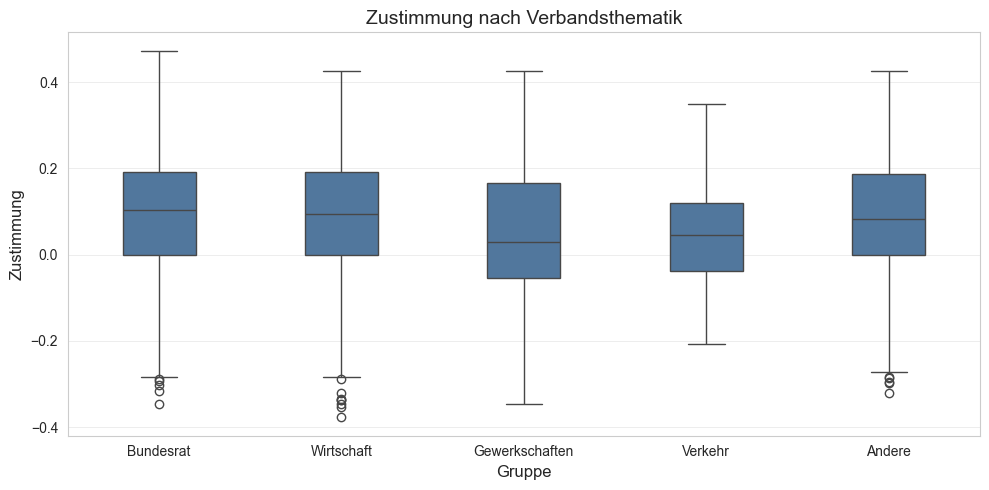

In [7]:
boxplot(df_verb, x="gruppe", y="zustimmung",
        titel="Zustimmung nach Verbandsthematik",
        xlabel="Gruppe", ylabel="Zustimmung",
        figsize=(10, 5))

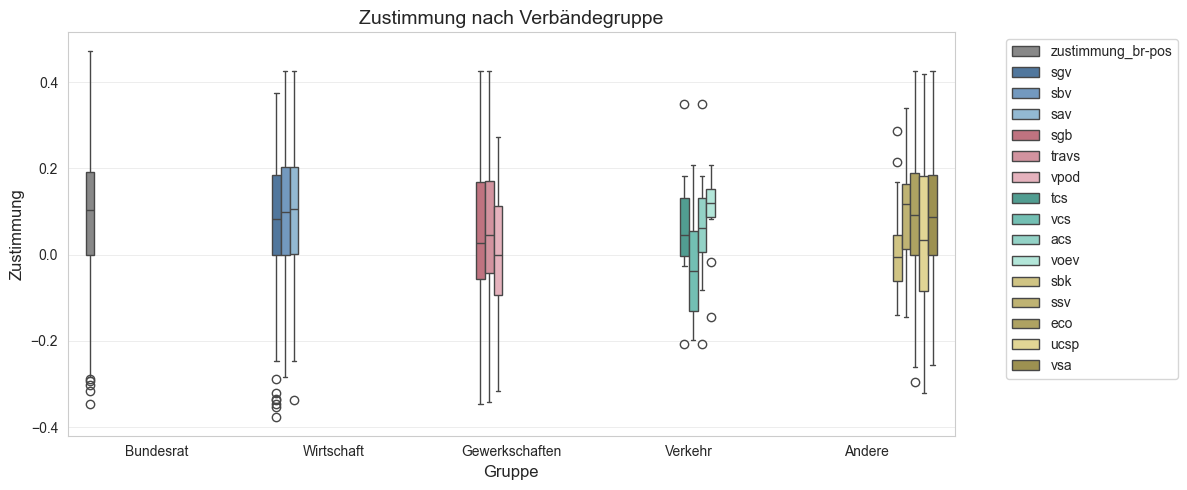

In [9]:
palette_gruppen = {
    'zustimmung_br-pos': '#888888',
    # Wirtschaft – Blautöne
    'sgv': '#4477AA', 'sbv': '#6699CC', 'sav': '#88BBDD',
    # Gewerkschaften – Rottöne
    'sgb': '#CC6677', 'travs': '#DD8899', 'vpod': '#EEA9B8',
    # Verkehr – Grüntöne
    'tcs': '#44AA99', 'vcs': '#66CCBB', 'acs': '#88DDCC', 'voev': '#AAEEDD',
    # Andere – Sand/Gelbtöne
    'sbk': '#DDCC77', 'ssv': '#CCBB66', 'eco': '#BBAA55', 'ucsp': '#EEDD88', 'vsa': '#AA9944'
}
boxplot(df_verb, x="gruppe", y="zustimmung", hue="organisation",
        titel="Zustimmung nach Verbändegruppe",
        xlabel="Gruppe", ylabel="Zustimmung", palette = palette_gruppen,
        figsize=(12, 5), width = 0.8)

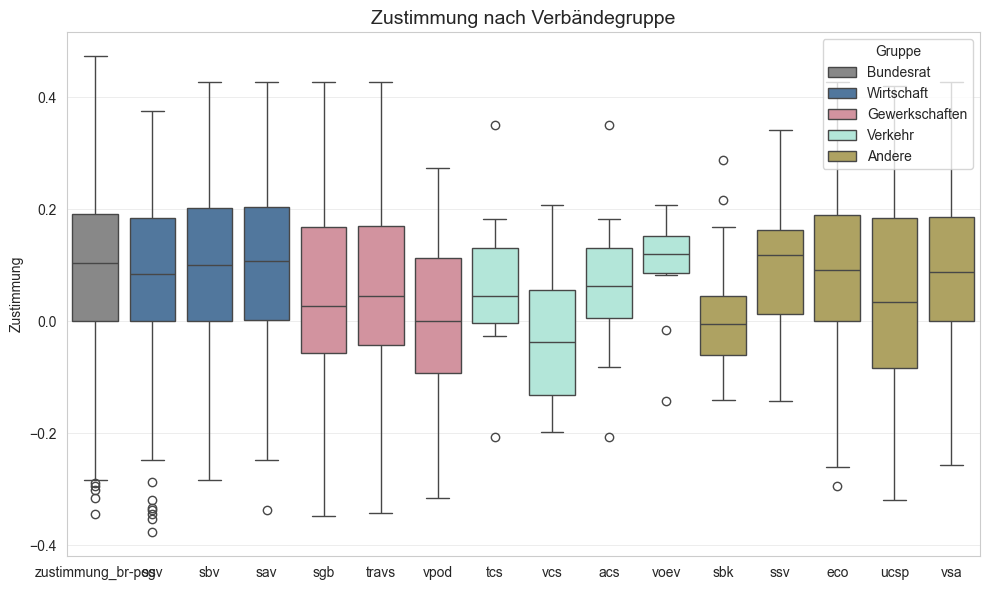

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_verb, x='organisation', y='zustimmung',
            hue='gruppe', dodge=False,
            palette={'Bundesrat': '#888888', "Wirtschaft": "#4477AA", "Gewerkschaften": "#DD8899",
                     "Verkehr": "#AAEEDD", "Andere": "#BBAA55"},
            width=0.8, gap=0, ax=ax)

ax.set_title('Zustimmung nach Verbändegruppe', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Zustimmung')
ax.legend(title='Gruppe', loc='upper right')
plt.tight_layout()
plt.show()